In [1]:
!pip3 install opencv-python numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 44.6 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [3]:

import numpy as np
import matplotlib.pyplot as plt
import cv2


In [5]:
image = cv2.imread("./photos/sudoku.png")
# convert to grayscale
grayscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# perform edge detection
edges = cv2.Canny(grayscale, 30, 100)


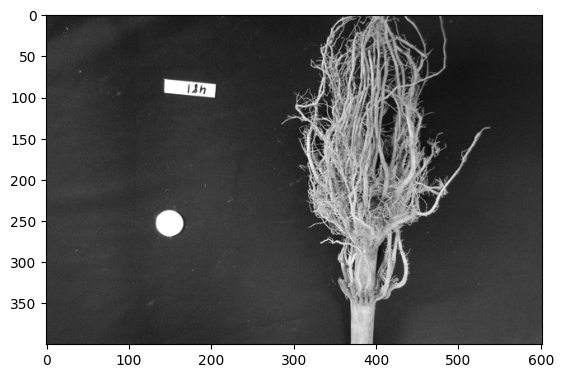

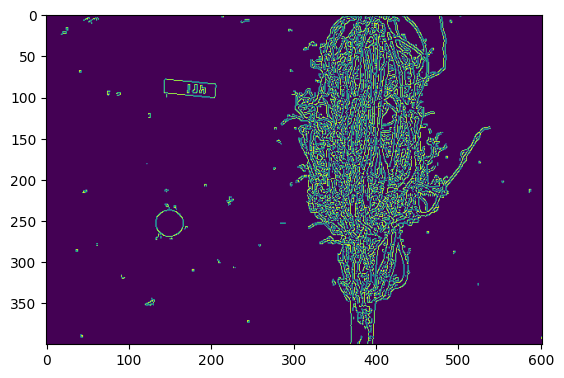

In [7]:
image = cv2.imread("./photos/maize-root-cluster.jpg")
# convert it to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# show the grayscale image
plt.imshow(gray, cmap="gray")
plt.show()
# perform the canny edge detector to detect image edges
edges = cv2.Canny(gray, threshold1=30, threshold2=100)
plt.imshow(edges)


In [8]:
image = cv2.imread("./photos/maize-root-cluster.jpg")
# convert to grayscale
grayscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# perform edge detection
edges = cv2.Canny(grayscale, 30, 100)
# detect lines in the image using hough lines technique
lines = cv2.HoughLinesP(edges, 1, np.pi/180, 60, np.array([]), 50, 5)


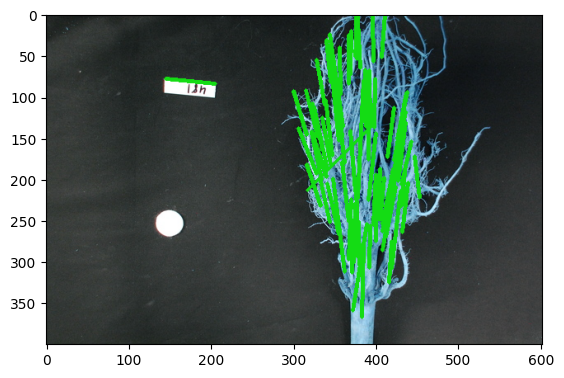

In [9]:
# iterate over the output lines and draw them
for line in lines:
    for x1, y1, x2, y2 in line:
        cv2.line(image, (x1, y1), (x2, y2), (20, 220, 20), 3)

# show the image
plt.imshow(image)
plt.show()


In [10]:
# load the image
img = cv2.imread("./photos/maize-root-cluster.jpg")
# convert BGR to RGB to be suitable for showing using matplotlib library
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# make a copy of the original image
cimg = img.copy()
# convert image to grayscale
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# apply a blur using the median filter
img = cv2.medianBlur(img, 5)


In [11]:
# finds the circles in the grayscale image using the Hough transform
circles = cv2.HoughCircles(image=img, method=cv2.HOUGH_GRADIENT, dp=0.9, 
                            minDist=80, param1=110, param2=39, maxRadius=70)


Number of circles detected: 5


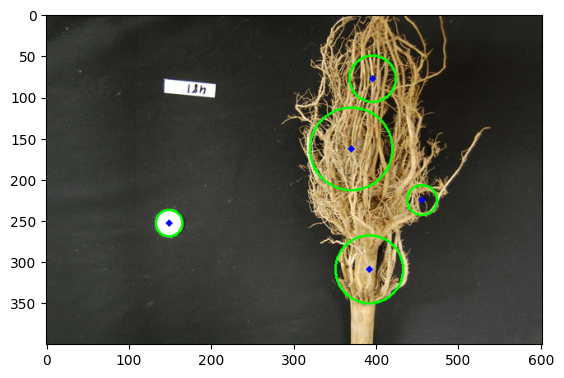

In [13]:
for co, i in enumerate(circles[0, :], start=1):
    x, y, r = int(i[0]), int(i[1]), int(i[2])

    # draw the outer circle in green
    cv2.circle(cimg, (x, y), r, (0, 255, 0), 2)

    # draw the center of the circle in blue
    cv2.circle(cimg, (x, y), 2, (0, 0, 255), 3)

print("Number of circles detected:", co)

plt.imshow(cimg)
plt.show()

In [14]:
import cv2
import numpy as np

cap = cv2.VideoCapture(0)

while True:
    ret, image = cap.read()
    if not ret:
        print("Camera could not be read.")
        break

    # convert to grayscale
    grayscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # perform edge detection
    edges = cv2.Canny(grayscale, 30, 100)

    # detect lines in the image using Hough Lines
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 60, minLineLength=50, maxLineGap=5)

    # iterate over the output lines and draw them
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv2.line(image, (x1, y1), (x2, y2), (255, 0, 0), 3)
            cv2.line(edges, (x1, y1), (x2, y2), 255, 3)

    # show images
    cv2.imshow("image", image)
    cv2.imshow("edges", edges)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

2026-03-11 23:02:45.149 Python[24847:580107] WARNING: AVCaptureDeviceTypeExternal is deprecated for Continuity Cameras. Please use AVCaptureDeviceTypeContinuityCamera and add NSCameraUseContinuityCameraDeviceType to your Info.plist.


Camera could not be read.


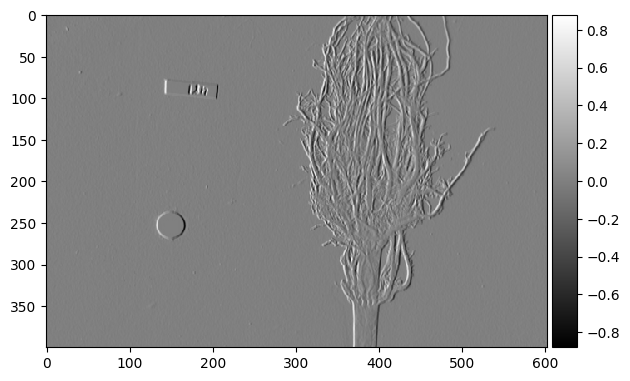

In [15]:
#importing the required libraries
import numpy as np
from skimage.io import imread, imshow
from skimage.filters import prewitt_h,prewitt_v
import matplotlib.pyplot as plt
%matplotlib inline
#reading the image 
image = imread(("./photos/maize-root-cluster.jpg"),as_gray=True)
#calculating horizontal edges using prewitt kernel
edges_prewitt_horizontal = prewitt_h(image)
#calculating vertical edges using prewitt kernel
edges_prewitt_vertical = prewitt_v(image)
imshow(edges_prewitt_vertical, cmap='gray')


(400, 602, 3)


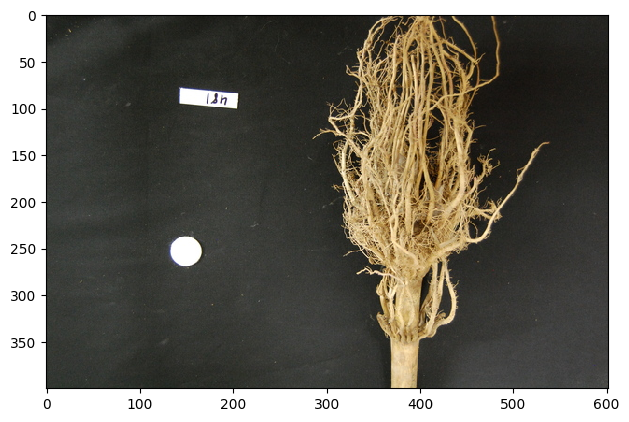

In [16]:
#importing required libraries
from skimage.io import imread, imshow
from skimage.transform import resize
from skimage.feature import hog
from skimage import exposure
import matplotlib.pyplot as plt
%matplotlib inline

img = imread("./photos/maize-root-cluster.jpg")
imshow(img)
print(img.shape)


(128, 64, 3)


(3780,)

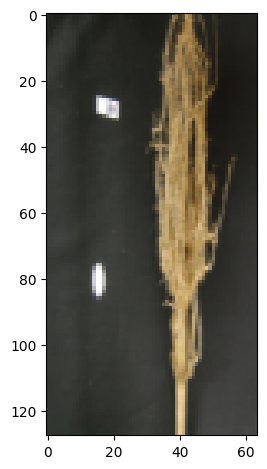

In [18]:
#resizing image 
resized_img = resize(img, (128,64)) 
imshow(resized_img) 
print(resized_img.shape)

#creating hog features 
fd, hog_image = hog(resized_img, orientations=9, pixels_per_cell=(8, 8), 
                    cells_per_block=(2, 2), visualize=True, channel_axis=-1)
fd.shape


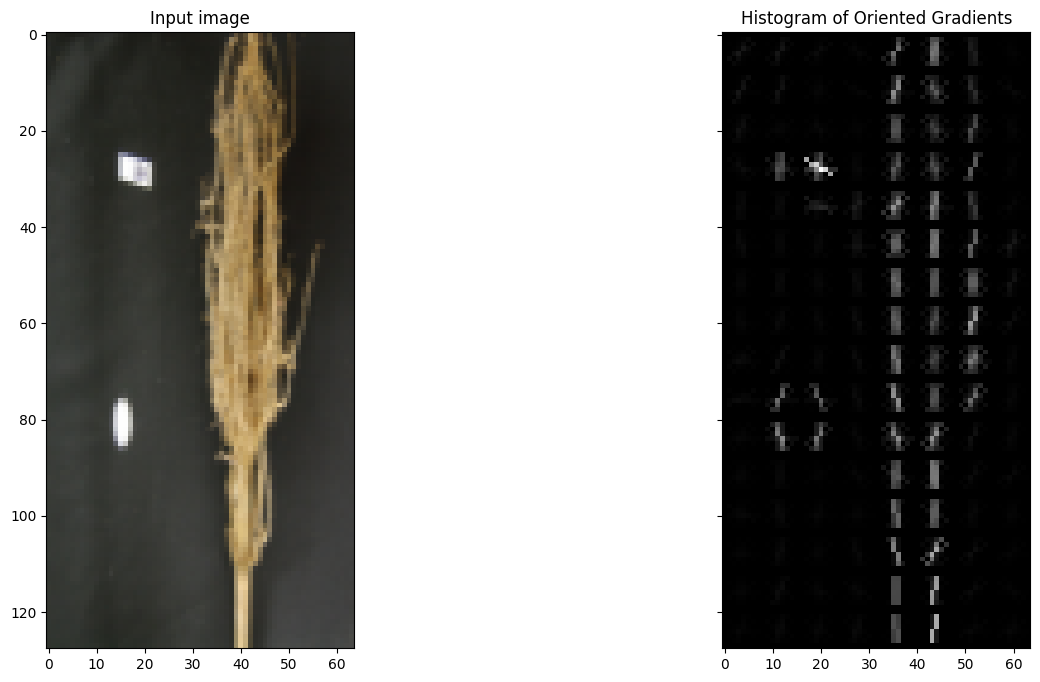

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharex=True, sharey=True) 
ax1.imshow(resized_img, cmap=plt.cm.gray) 
ax1.set_title('Input image') 

# Rescale histogram for better display 
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10)) 
ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray) 
ax2.set_title('Histogram of Oriented Gradients')

plt.show()
